In [1]:
# importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [2]:
# Load Required Data

nav = pd.read_csv("../data/processed/clean_nav.csv")
performance = pd.read_csv("../data/processed/clean_performance.csv")
benchmark = pd.read_csv("../data/processed/clean_benchmark_indices.csv")

In [3]:
# Task 1 — Compute Daily Returns
# Convert dates:

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [4]:
# Check columns

nav.info()
nav.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   amfi_code     46000 non-null  int64         
 1   date          46000 non-null  datetime64[ns]
 2   nav           46000 non-null  float64       
 3   daily_return  45960 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 1.4 MB


,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-1.030568
2,100016,2022-01-05,521.7239,1.286515
3,100016,2022-01-06,515.7880,-1.137747
4,100016,2022-01-07,515.1639,-0.120999


In [5]:
# sort the nav data
nav = nav.sort_values(
    ["amfi_code","date"]
)

In [6]:
# compute dialy returns

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]    # Daily Return=NAVt/1​NAVt​​−1
    .pct_change()
)


In [7]:
# inspect results
nav.head(15)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [8]:
# Annualized Return       Formula (1+r1​)(1+r2​)⋯(1+rn​)252/n−1

annual_return = (
    nav.groupby("amfi_code")["daily_return"]
    .apply(
        lambda x:
        (1 + x.dropna()).prod() ** (252 / len(x.dropna())) -1
    )
    .reset_index()
)

annual_return.columns = [ "amfi_code","annual_return"]  #  (1+r1​)(1+r2​)⋯(1+rn​)252/n−1

In [14]:
nav.head(15)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [19]:
# Daily Return

nav = pd.read_csv("../data/processed/clean_nav.csv")               # Daily Return=NAVt/1​NAVt​​−1
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.to_csv(
    "../data/processed/returns_computed.csv",
    index=False
)

In [18]:
# Merge Scheme Names

annual_return = annual_return.merge(
    performance[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [17]:
annual_return.head()

,amfi_code,annual_return,scheme_name
0,100016,0.025435,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042987,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.289279,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.226265,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.076502,ABSL Small Cap Fund - Regular - Growth


In [20]:
# Verify File
annual_return.shape
annual_return.describe()

,amfi_code,annual_return
count,40.000000,40.000000
mean,120247.000000,0.160894
std,14534.998667,0.098930
min,100016.000000,0.011304
25%,118632.750000,0.066136
50%,119551.500000,0.159811
75%,120842.250000,0.235362
max,149324.000000,0.315124


In [21]:
# Task 2 — Calculate CAGR 

# Copy NAV Data
cagr_data = nav.copy()

In [22]:
# Latest NAV of Each Fund
latest_nav = (
    cagr_data
    .sort_values("date")
    .groupby("amfi_code")
    .last()
    .reset_index()
)

latest_nav = latest_nav[
    ["amfi_code", "date", "nav"]
]

latest_nav.rename(
    columns={
        "date":"latest_date",
        "nav":"latest_nav"
    },
    inplace=True
)

latest_nav.head()

,amfi_code,latest_date,latest_nav
0,100016,2026-05-29,583.6113
1,100025,2026-05-29,31.8843
2,100033,2026-05-29,342.0072
3,101206,2026-05-29,773.2939
4,101207,2026-05-29,53.9836


In [16]:
# Create Function to Calculate CAGR
def calculate_cagr(df, years):

    result = []

    latest = (
        df.sort_values("date")
          .groupby("amfi_code")
          .last()
    )

    for fund in df["amfi_code"].unique():

        fund_df = (
            df[df["amfi_code"] == fund]
            .sort_values("date")
        )

        end_date = fund_df["date"].max()

        start_date = end_date - pd.DateOffset(years=years)

        start_rows = fund_df[
            fund_df["date"] >= start_date
        ]

        if len(start_rows) == 0:
            continue

        start_nav = start_rows.iloc[0]["nav"]
        end_nav = fund_df.iloc[-1]["nav"]

        cagr = (
            (end_nav / start_nav) ** (1 / years)
        ) - 1

        result.append(
            {
                "amfi_code": fund,
                f"cagr_{years}yr": cagr
            }
        )

    return pd.DataFrame(result)

In [17]:
# calculate the cagr
cagr_1 = calculate_cagr(cagr_data, 1)

cagr_3 = calculate_cagr(cagr_data, 3)

cagr_5 = calculate_cagr(cagr_data, 5)

In [18]:
# merging all cagr values
cagr_report = (
    cagr_1
    .merge(cagr_3, on="amfi_code")
    .merge(cagr_5, on="amfi_code")
)

In [19]:
# add scheme names
cagr_report = cagr_report.merge(
    performance[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [20]:
# rearrange the columns
cagr_report = cagr_report[
    [
        "amfi_code",
        "scheme_name",
        "cagr_1yr",
        "cagr_3yr",
        "cagr_5yr"
    ]
]

In [21]:
# convert percentage
cagr_report["cagr_1yr"] *= 100
cagr_report["cagr_3yr"] *= 100
cagr_report["cagr_5yr"] *= 100

cagr_report = cagr_report.round(2)

In [22]:
# save cagr file
cagr_report.to_csv(
    "../data/processed/cagr_report.csv",
    index=False
)

In [23]:
cagr_report.head()

#cagr_report.describe()

#cagr_report.shape

,amfi_code,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.22,1.29,2.32
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.70,3.92,3.91
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.23,32.44,26.07
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.92,28.97,20.44
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.99,-4.15,6.95


In [24]:
cagr_report["cagr_1yr"] = (cagr_report["cagr_1yr"] * 100).round(2)
cagr_report["cagr_3yr"] = (cagr_report["cagr_3yr"] * 100).round(2)
cagr_report["cagr_5yr"] = (cagr_report["cagr_5yr"] * 100).round(2)

cagr_report.head()

,amfi_code,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-222.0,129.0,232.0
1,100025,HDFC Short Term Debt Fund - Regular - Growth,370.0,392.0,391.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,5323.0,3244.0,2607.0
3,101206,ABSL Frontline Equity Fund - Regular - Growth,4792.0,2897.0,2044.0
4,101207,ABSL Small Cap Fund - Regular - Growth,-2399.0,-415.0,695.0


In [26]:
cagr_report.to_csv(
    "../data/processed/cagr_report.csv",
    index=False
)

In [27]:
# Task 3 — Compute Sharpe Ratio
 # Calculate the Sharpe Ratio for every fund.

# Where:

# Rp = Mean daily return
# Rf = Risk-free rate = 6.5% = 0.065
# σ = Standard deviation of daily returns
# √252 = Annualization factor

In [28]:
# Set Risk-Free Rate
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

In [29]:
# Calculate Sharpe Ratio
sharpe = (
    nav.groupby("amfi_code")["daily_return"]
       .apply(
           lambda x: (
               (x.mean() - daily_rf)
               / x.std()
           ) * np.sqrt(252)
       )
       .reset_index()
)

In [30]:
# Rename Column
sharpe.columns = [
    "amfi_code",
    "sharpe_ratio"
]

In [31]:
# Merge Scheme Names
sharpe = sharpe.merge(
    performance[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [32]:
# Rearrange Columns
sharpe = sharpe[
    [
        "amfi_code",
        "scheme_name",
        "sharpe_ratio"
    ]
]

In [33]:
# Sort by Best Funds
sharpe = sharpe.sort_values(
    "sharpe_ratio",
    ascending=False
)

In [34]:
# Round Values
sharpe["sharpe_ratio"] = sharpe["sharpe_ratio"].round(3)

In [35]:
# Save CSV
sharpe.to_csv(
    "../data/processed/sharpe_values.csv",
    index=False
)

In [36]:
sharpe.head()

#sharpe.describe()


,amfi_code,scheme_name,sharpe_ratio
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.448
30,120843,Kotak Flexicap Fund - Regular - Growth,1.307
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.235
19,119551,SBI Bluechip Fund - Regular Plan - Growth,1.208
25,120505,ICICI Pru Midcap Fund - Regular - Growth,1.180


In [38]:
# Task 4 – Compute Sortino Ratio
 # Calculate the Sortino Ratio for all 40 funds.

# Rp = Mean daily return
# Rf = Risk-free rate (6.5%)
# σd = Standard deviation of negative daily returns only

In [39]:
# Set Risk-Free Rate
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

In [41]:
# create function
def calculate_sortino(x):

    # Remove missing values
    x = x.dropna()

    # Only negative return days
    downside = x[x < 0]

    # If there are too few negative returns
    if len(downside) < 2:
        return np.nan

    downside_std = downside.std()

    if downside_std == 0:
        return np.nan

    sortino = (
        (x.mean() - daily_rf)
        / downside_std
    ) * np.sqrt(252)

    return sortino

In [42]:
# Calculate Sortino Ratio
sortino = (
    nav.groupby("amfi_code")["daily_return"]
       .apply(calculate_sortino)
       .reset_index()
)

In [43]:
# Rename Column
sortino.columns = [
    "amfi_code",
    "sortino_ratio"
]

In [44]:
# Merge Scheme Name
sortino = sortino.merge(
    performance[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [45]:
# Rearrange Columns
sortino = sortino[
    [
        "amfi_code",
        "scheme_name",
        "sortino_ratio"
    ]
]

In [46]:
# Round Values
sortino["sortino_ratio"] = sortino["sortino_ratio"].round(3)

In [47]:
# Rank Funds
sortino = sortino.sort_values(
    "sortino_ratio",
    ascending=False
)

In [48]:
# Save CSV
sortino.to_csv(
    "../data/processed/sortino_values.csv",
    index=False
)

In [49]:
sortino.head()
# sortino.describe()

,amfi_code,scheme_name,sortino_ratio
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,2.386
30,120843,Kotak Flexicap Fund - Regular - Growth,2.364
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,2.147
19,119551,SBI Bluechip Fund - Regular Plan - Growth,2.140
25,120505,ICICI Pru Midcap Fund - Regular - Growth,2.029


In [56]:
# Task 5 – Alpha & Beta

# Calculate:

# Beta = Slope of regression
# Alpha = Intercept × 252 (annualized)

# using NIFTY 100 as the benchmark.
# where
      # Rf​=α+βRm​
# Rf= Fund daily return
# Rm= Benchmark daily return

In [57]:
# Prepare Benchmark Data

benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [58]:
# Calculate Benchmark Daily Returns
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [59]:
# Keep Required Columns
nifty100 = nifty100[
    [
        "date",
        "benchmark_return"
    ]
]

In [60]:
# Merge Fund Returns with Benchmark Returns
merged = nav.merge(
    nifty100,
    on="date",
    how="inner"
)

In [61]:
merged.head()

# merged.shape

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003
3,100016,2022-01-06,515.7880,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.006150


In [96]:
# calculate alpha & beta

alpha_beta = []
for fund in merged["amfi_code"].unique():

    df = merged[
        merged["amfi_code"] == fund
    ].dropna()

    if len(df) < 30:
        continue

    result = linregress(
        df["benchmark_return"],
        df["daily_return"]
    )

    alpha_beta.append({

        "amfi_code": fund,

        "alpha": result.intercept * 252,

        "beta": result.slope,

        "r_squared": result.rvalue**2

    })

In [99]:
# Convert to DataFrame
alpha_beta = pd.DataFrame(alpha_beta)

In [105]:
print("alpha_beta type:", type(alpha_beta))
print("performance type:", type(performance))

print(alpha_beta.columns)
print(performance.columns)

alpha_beta = alpha_beta.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print("Merge Successful!")
print(alpha_beta.head())

alpha_beta type: <class 'pandas.core.frame.DataFrame'>
performance type: <class 'pandas.core.frame.DataFrame'>
Index(['amfi_code', 'alpha', 'beta', 'r_squared'], dtype='object')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade', 'anomaly_flag',
       'expense_ratio_valid'],
      dtype='object')
Merge Successful!
   amfi_code     alpha      beta  r_squared  \
0     100016  0.037476 -0.058268   0.002665   
1     100025  0.042818  0.001158   0.000015   
2     100033  0.271954  0.005104   0.000012   
3     101206  0.213998  0.021086   0.000348   
4     101207  0.108971 -0.065289   0.001064   

                                         scheme_name  
0          HDFC Top 100 Fund - Regular Plan - Growth  
1       HDF

In [114]:
print(alpha_beta.columns.tolist())
print(performance.columns.tolist())

['amfi_code', 'alpha', 'beta', 'r_squared', 'scheme_name_x', 'scheme_name_y', 'scheme_name']
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'anomaly_flag', 'expense_ratio_valid']


In [115]:
# Round Values
alpha_beta[
    [
        "alpha",
        "beta",
        "r_squared"
    ]
] = alpha_beta[
    [
        "alpha",
        "beta",
        "r_squared"
    ]
].round(4)

In [116]:
# Save CSV
alpha_beta.to_csv(

    "../data/processed/alpha_beta.csv",

    index=False

)

In [117]:
alpha_beta.head()
alpha_beta.describe()


,amfi_code,alpha,beta,r_squared
count,40.000000,40.000000,40.000000,40.000000
mean,120247.000000,0.159083,-0.001958,0.000605
std,14534.998667,0.087529,0.035203,0.000731
min,100016.000000,0.029000,-0.067000,0.000000
25%,118632.750000,0.068625,-0.023950,0.000075
50%,119551.500000,0.162300,-0.000050,0.000300
75%,120842.250000,0.221725,0.017050,0.001025
max,149324.000000,0.303400,0.103500,0.002800


In [118]:
# Task 6 – Compute Maximum Drawdown
  #For each mutual fund:

# Compute the running maximum NAV.
# Compute the drawdown.
# Find the maximum (worst) drawdown.
# Save the results in max_drawdown.csv.

 # Drawdown=NAV/Running Max NAV​ −1

In [119]:
# Create a Copy
mdd = nav.copy()

In [120]:
# Sort the Data
mdd = mdd.sort_values(
    ["amfi_code", "date"]
)

In [121]:
# Calculate Running Maximum NAV
mdd["running_max"] = (
    mdd.groupby("amfi_code")["nav"]
       .cummax()
)

In [122]:
# Calculate Drawdown
mdd["drawdown"] = (
    mdd["nav"] / mdd["running_max"]
) - 1

In [123]:
# Find Maximum Drawdown for Each Fund
max_drawdown = (
    mdd.groupby("amfi_code")
       .agg(
           max_drawdown=("drawdown", "min"),
           worst_date=("date", "min")
       )
       .reset_index()
)

In [124]:
# Merge Scheme Name
max_drawdown = max_drawdown.merge(
    performance[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [125]:
# Rearrange Columns
max_drawdown = max_drawdown[
    [
        "amfi_code",
        "scheme_name",
        "max_drawdown",
        "worst_date"
    ]
]

In [126]:
# Convert to Percentage
max_drawdown["max_drawdown"] = (
    max_drawdown["max_drawdown"] * 100
).round(2)

In [127]:
# Sort by Worst Drawdown
max_drawdown = max_drawdown.sort_values(
    "max_drawdown"
)

In [128]:
# Save CSV
max_drawdown.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

In [129]:
max_drawdown.head()


,amfi_code,scheme_name,max_drawdown,worst_date
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-52.57,2022-01-03
17,119095,Axis Small Cap Fund - Regular - Growth,-51.68,2022-01-03
4,101207,ABSL Small Cap Fund - Regular - Growth,-35.45,2022-01-03
39,149324,DSP Small Cap Fund - Regular - Growth,-31.17,2022-01-03
21,119598,SBI Small Cap Fund - Regular Plan - Growth,-28.71,2022-01-03


In [130]:
# Task 7 – Fund Scorecard

# Create a 0–100 composite score using the following weights:

# Metric	       Weight
# 3-Year CAGR	     30%
# Sharpe Ratio	     25%
# Alpha	              20%
# Expense Ratio (Inverse Rank)	15%
# Maximum Drawdown (Inverse Rank)	10%

In [131]:
# Load Required Data
cagr = pd.read_csv("../data/processed/cagr_report.csv")

sharpe = pd.read_csv("../data/processed/sharpe_values.csv")

max_dd = pd.read_csv("../data/processed/max_drawdown.csv")

performance = pd.read_csv("../data/processed/clean_performance.csv")

In [132]:
# Load Alpha data

alpha = pd.read_csv("../data/processed/alpha_beta.csv")

In [136]:
scorecard = (
    performance[
        [
            "amfi_code",
            "scheme_name",
            "expense_ratio_pct"
        ]
    ]
    .merge(
        cagr[
            ["amfi_code", "cagr_3yr"]
        ],
        on="amfi_code",
        how="left"
    )
    .merge(
        sharpe[
            ["amfi_code", "sharpe_ratio"]
        ],
        on="amfi_code",
        how="left"
    )
    .merge(
        alpha[
            [
                "amfi_code",
                "alpha",
                "beta",
                "r_squared"
            ]
        ],
        on="amfi_code",
        how="left"
    )
    .merge(
        max_dd[
            [
                "amfi_code",
                "max_drawdown"
            ]
        ],
        on="amfi_code",
        how="left"
    )
)

In [137]:
# Create Ranks
  # Higher values are better for CAGR, Sharpe, and Alpha.
  # Lower values are better for Expense Ratio and Maximum Drawdown.

scorecard["cagr_rank"] = (
    scorecard["cagr_3yr"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=True)
)

In [138]:
# calucat  weighted score
scorecard["fund_score"] = (

      scorecard["cagr_rank"] * 0.30

    + scorecard["sharpe_rank"] * 0.25

    + scorecard["alpha_rank"] * 0.20

    + scorecard["expense_rank"] * 0.15

    + scorecard["drawdown_rank"] * 0.10

)

In [140]:
# Convert to a 0–100 Score
max_score = scorecard["fund_score"].max()

scorecard["fund_score"] = (

    100

    - (scorecard["fund_score"] / max_score * 100)

).round(2)

In [141]:
# Rank Funds
scorecard = scorecard.sort_values(

    "fund_score",

    ascending=False

)

In [143]:
# final columns 
scorecard = scorecard[
    [
        "amfi_code",

        "scheme_name",

        "cagr_3yr",

        "sharpe_ratio",

        "alpha",

        "expense_ratio_pct",

        "max_drawdown",

        "fund_score"
    ]
]

In [144]:
# Save CSV
scorecard.to_csv(

    "../data/processed/fund_scorecard.csv",

    index=False

)

In [145]:
scorecard.head(10)

,amfi_code,scheme_name,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,fund_score
24,119092,Axis Bluechip Fund - Regular - Growth,53.0,0.031,0.0690,1.64,-14.40,100.00
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,129.0,-0.202,0.0375,1.55,-24.73,97.97
32,102886,UTI Mid Cap Fund - Regular - Growth,-77.0,-0.206,0.0290,1.51,-28.00,97.29
9,100025,HDFC Short Term Debt Fund - Regular - Growth,392.0,-0.567,0.0428,0.56,-4.31,94.11
30,101208,ABSL Liquid Fund - Regular - Growth,632.0,-0.816,0.0609,0.79,-0.16,93.33
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,584.0,-0.227,0.0562,0.77,-4.33,90.44
27,119095,Axis Small Cap Fund - Regular - Growth,-1171.0,-0.076,0.0480,1.38,-51.68,89.66
19,118636,Nippon India Gilt Securities Fund - Regular - ...,406.0,-0.357,0.0507,0.55,-8.32,88.30
29,101207,ABSL Small Cap Fund - Regular - Growth,-415.0,0.163,0.1090,1.53,-35.45,83.00
23,120844,Kotak Liquid Fund - Regular - Growth,670.0,-0.089,0.0646,0.60,-0.12,81.35


In [146]:
# Task 8 – Benchmark Comparison Chart
# Objective
 # Compare the Top 5 funds with NIFTY 50 and NIFTY 100
 # Create a publication-quality line chart

In [147]:
# convert dates
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [148]:
# Select Top 5 Funds

top5 = (
    cagr.sort_values("cagr_3yr", ascending=False)
        .head(5)
)

top5_codes = top5["amfi_code"].tolist()

In [149]:
# Filter NAV Data
top5_nav = nav[
    nav["amfi_code"].isin(top5_codes)
].copy()

In [150]:
# Merge Scheme Names
top5_nav = top5_nav.merge(
    performance[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [153]:
# Normalize NAV (Base = 100)
top5_nav["normalized_nav"] = (
    top5_nav.groupby("scheme_name")["nav"]
            .transform(lambda x: x / x.iloc[0] * 100)
)

In [154]:
# Prepare Benchmark
benchmark_filtered = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

In [155]:
# Normalize Benchmark
benchmark_filtered["normalized_value"] = (
    benchmark_filtered.groupby("index_name")["close_value"]
                      .transform(lambda x: x / x.iloc[0] * 100)
)

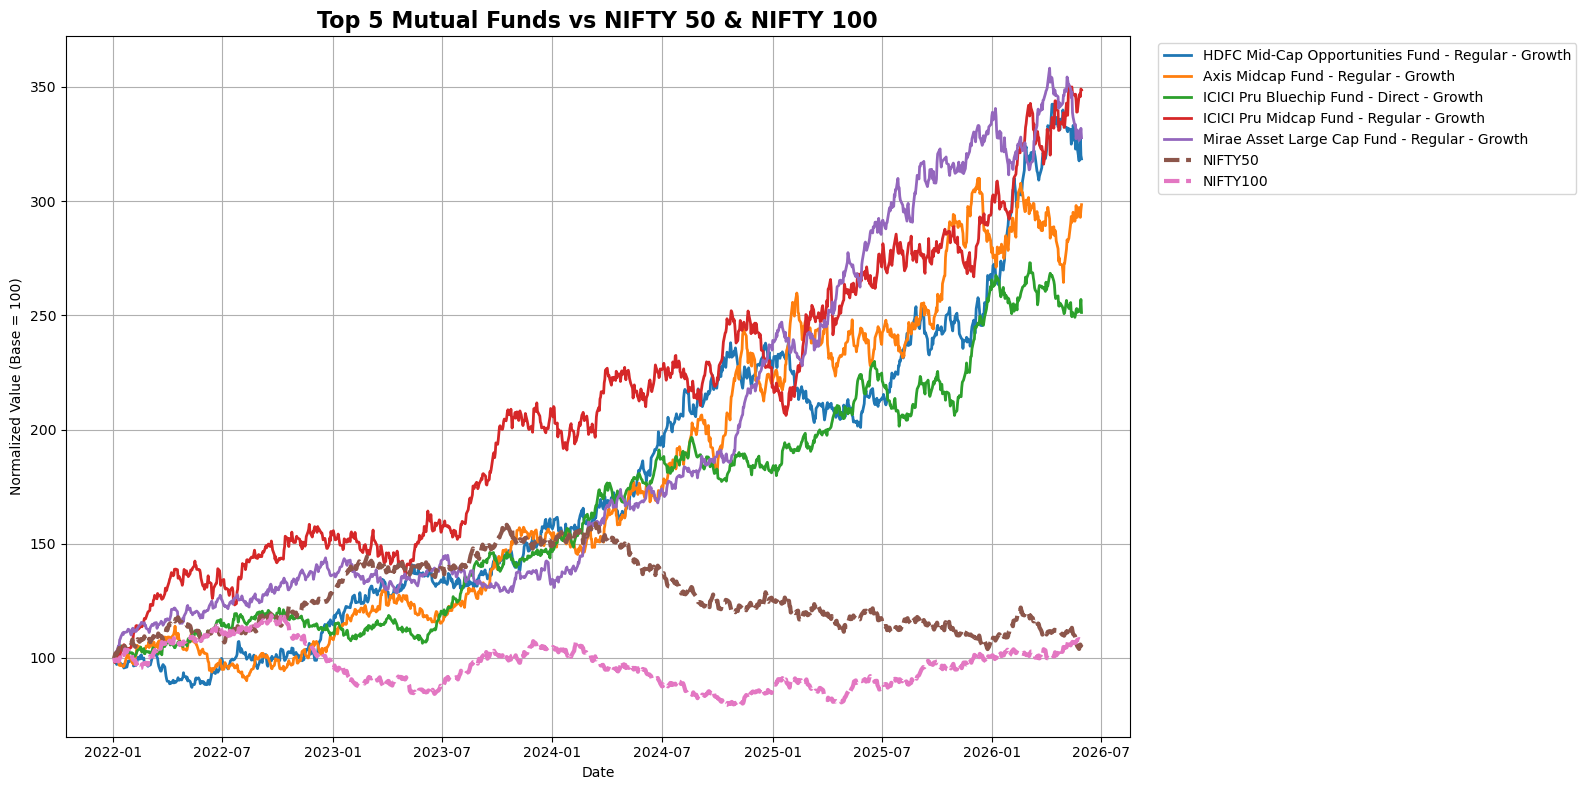

In [157]:
# Plot 

plt.figure(figsize=(16,8))

# Top 5 Funds
for scheme in top5_nav["scheme_name"].unique():

    temp = top5_nav[
        top5_nav["scheme_name"] == scheme
    ]

    plt.plot(
        temp["date"],
        temp["normalized_nav"],
        linewidth=2,
        label=scheme
    )

# Benchmarks
for idx in benchmark_filtered["index_name"].unique():

    temp = benchmark_filtered[
        benchmark_filtered["index_name"] == idx
    ]

    plt.plot(
        temp["date"],
        temp["normalized_value"],
        linestyle="--",
        linewidth=3,
        label=idx
    )

plt.title(
    "Top 5 Mutual Funds vs NIFTY 50 & NIFTY 100",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.grid(True)

plt.tight_layout()


# save the chart
plt.savefig(
    "../reports/query_results/charts/benchmark_comparison_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()